<>:20: SyntaxWarning: invalid escape sequence '\/'
<>:20: SyntaxWarning: invalid escape sequence '\/'
/tmp/ipykernel_35424/3371002130.py:20: SyntaxWarning: invalid escape sequence '\/'
  lixo = '.,>.?!"`():[][]\/|#$^&*'
[nltk_data] Downloading package stopwords to /home/pedro/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /home/pedro/nltk_data...
[nltk_data]   Package rslp is already up-to-date!
[nltk_data] Downloading package machado to /home/pedro/nltk_data...
[nltk_data]   Package machado is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/pedro/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Conteúdo original do arquivo:
['O', 'rÁpido_trator-amarelo', '(mod.', '2024!)', 'saltou', 'sobre', 'o', 'cão', 'preguiçoso...', 'OU', 'NÃO?', 'Atenção:', 'o', 'e-mail', 'de', 'contato', 'é', 'suporte_técnico@empresa-x.com.br.', 'Não', 'esqueça!!!', 'Havia', 'cerca', 'de', '1.250,50', 'kg', 'de', 'resíduos', 'na', 'área', '@setor_norte.']
------------------------------
Conteúdo do arquivo limpo:
['o', 'rápido_trator-amarelo', 'mod', 'saltou', 'sobre', 'o', 'cão', 'preguiçoso', 'ou', 'não', 'atenção', 'o', 'e-mail', 'de', 'contato', 'é', 'suporte_técnico@empresa-x.com.br', 'não', 'esqueça', 'havia', 'cerca', 'de', 'kg', 'de', 'resíduos', 'na', 'área']


['banana', 'maçã', 'melancia']
22
0.8148148148148148
o 	 3
de 	 3
não 	 2
rápido_trator-amarelo 	 1
mod 	 1
saltou 	 1
sobre 	 1
cão 	 1
preguiçoso 	 1
ou 	 1
['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'às', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois', 'do', 'd

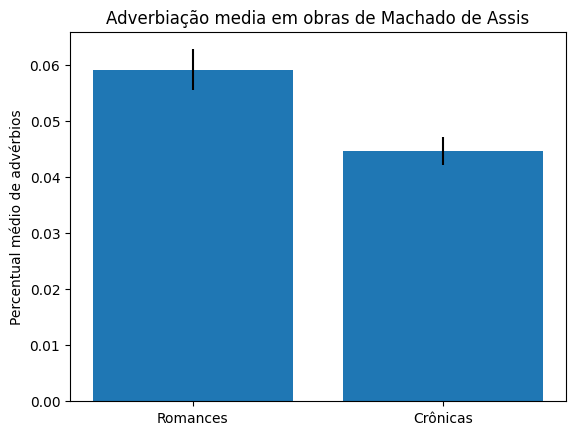

In [ ]:
from collections import defaultdict
import nltk

import statistics as stat
from nltk.corpus import machado

import spacy

import matplotlib.pyplot as plt

nlp = spacy.load('pt_core_news_sm')


nltk.download('stopwords') # Adicione isso
nltk.download('rslp')
nltk.download('machado')
nltk.download('punkt_tab')

def limpar(text):
    lixo = '.,>.?!"`():[][]\/|#$^&*'
    quase_limpo = [x.strip(lixo).lower() for x in text]
    return [x for x in quase_limpo if x.isalpha() or '-' in x]


with open('arquivo.txt', 'r', encoding='utf-8') as f:
    conteudo_bruto = f.read()

tokens_do_arquivo = conteudo_bruto.split()


print("Conteúdo original do arquivo:")
print(tokens_do_arquivo)
print("-" * 30)

lista_palavras = limpar(tokens_do_arquivo)
print("Conteúdo do arquivo limpo:")
print(lista_palavras)

corpus_sujo = ['banana', 'maçã.', 'abaca.te', ':MeLancia']
print("\n")
print(limpar(corpus_sujo))


# step 1 - definir vocabulario
vocabulario = set(lista_palavras)
print(len(vocabulario))

riqueza = len(vocabulario) / len(lista_palavras)
print(riqueza)

def ocorrencias(lista_palavras):
    dicionario = defaultdict(int)
    for p in lista_palavras:
        dicionario[p] += 1
    return dicionario

dic = ocorrencias(lista_palavras)

mf = sorted(dic.items(), key=lambda tupla: tupla[1], reverse=True)[:10] # in haskell \(x,y) -> y
for palavra, n in mf:
    print(palavra, '\t',n)


# o, de, ou, sao palavras funcionais, servem para estabelecer relações, usar nltk para remover stopwords, ou seja, palavras funcionais, e focar nas palavras de conteudo, que tem mais significado.

vazias = nltk.corpus.stopwords.words('portuguese')
print(vazias)

frequentes_plenas = [x for x in mf if x[0].lower() not in vazias]
print("\n")
print(frequentes_plenas)


# hapax legomenon - palavras que ocorrem apenas uma vez em um texto, ou seja, tem frequencia 1
# hapax = [x for x in dic.items() if x[1] == 1]
# print("\n")
# print(hapax)

stemmer = nltk.stem.RSLPStemmer()
raizes = [stemmer.stem(x) for x in set(lista_palavras)]
hapax = [x for x in raizes if raizes.count(x) == 1]
print("\n")
print(hapax)

print(len(set(raizes)) / len(raizes))


print(machado.readme())


# etiquetagem morfossintática - atribuir a cada palavra uma etiqueta que indica sua categoria gramatical (substantivo, verbo, adjetivo, etc.)

doc = nlp('Será que vai funcionar essa etiquetagem?')
etiq = [(x.orth_, x.pos_) for x in doc]
print(etiq)


obras = list()

for i in range(1,6):
    obras.append('romance/marm0' + str(i) + '.txt')

for i in range(1,6):
    obras.append('cronica/macr0' + str(i) + '.txt')

cont_adv = list()

for obra in obras:
    print(obra)
    s = machado.raw(obra)
    doc = nlp(s)
    etiq = [(pal.orth_, pal.pos_) for pal in doc]
    adv = [(ort, pos) for (ort, pos) in etiq if pos == 'ADV']
    cont_adv.append(len(adv) / len(etiq))

rom_m = stat.mean(cont_adv[:4])
rom_dp = stat.stdev(cont_adv[:4])
cron_m = stat.mean(cont_adv[5:])
cron_dp = stat.stdev(cont_adv[5:])

print(f"Romances: média = {rom_m:.4f}, desvio padrão = {rom_dp:.4f}")
print(f"Crônicas: média = {cron_m:.4f}, desvio padrão = {cron_dp:.4f}")

tipo_obra=('Romances', 'Crônicas')

x=[0, 1]
media=[rom_m, cron_m]
dp=[rom_dp, cron_dp]

plt.bar(x, media, yerr=dp)
plt.xticks(x, tipo_obra)
plt.ylabel('Percentual médio de advérbios')
plt.title('Adverbiação media em obras de Machado de Assis')

plt.show()



Aqui criar o dicionario com as ocorrencias de classes gramaticais

In [6]:
lixo = ['PUNCT', 'SPACE', 'SYM', 'X', 'NUM']
pos2 = [pos for (pal, pos) in etiq if pos not in lixo]

print(pos2)

cont = defaultdict(int)
for pos in pos2:
    cont[pos] += 1

nomes = cont.keys()
ocorrencias = cont.values()

['PROPN', 'NOUN', 'VERB', 'PROPN', 'PROPN', 'NOUN', 'PROPN', 'PROPN', 'ADP', 'PROPN', 'ADP', 'PROPN', 'PROPN', 'PROPN', 'PROPN', 'VERB', 'ADV', 'ADP', 'PROPN', 'ADP', 'PROPN', 'ADP', 'PROPN', 'PROPN', 'ADP', 'PROPN', 'PROPN', 'ADP', 'PROPN', 'PROPN', 'ADP', 'NOUN', 'ADP', 'PROPN', 'PRON', 'SCONJ', 'PROPN', 'PROPN', 'ADV', 'VERB', 'PRON', 'VERB', 'DET', 'NOUN', 'CCONJ', 'PRON', 'AUX', 'ADP', 'ADJ', 'NOUN', 'CCONJ', 'DET', 'NOUN', 'ADP', 'NOUN', 'PRON', 'AUX', 'DET', 'ADJ', 'NOUN', 'ADJ', 'VERB', 'DET', 'NOUN', 'PRON', 'PRON', 'ADV', 'VERB', 'VERB', 'VERB', 'SCONJ', 'PROPN', 'PROPN', 'VERB', 'ADP', 'PRON', 'VERB', 'ADP', 'NOUN', 'ADJ', 'ADP', 'PROPN', 'PROPN', 'SCONJ', 'ADV', 'VERB', 'ADV', 'PRON', 'VERB', 'ADV', 'ADP', 'DET', 'NOUN', 'ADP', 'NOUN', 'ADP', 'NOUN', 'ADP', 'NOUN', 'ADP', 'NOUN', 'ADP', 'NOUN', 'ADP', 'NOUN', 'ADP', 'PROPN', 'ADP', 'NOUN', 'ADJ', 'ADV', 'PRON', 'VERB', 'ADP', 'NOUN', 'NOUN', 'CCONJ', 'NOUN', 'SCONJ', 'PRON', 'VERB', 'DET', 'NOUN', 'SCONJ', 'VERB', 'PRON', '

Aqui gerar o grafico

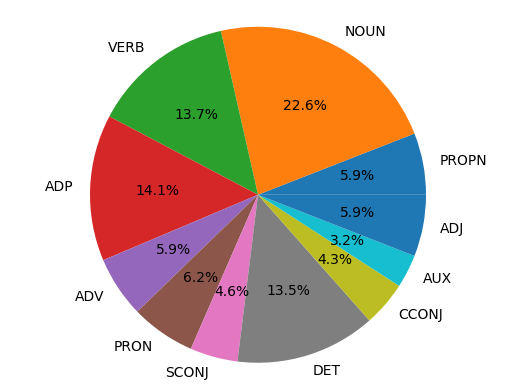

In [7]:
import matplotlib.pyplot as plt

plt.pie(ocorrencias, labels=nomes, autopct='%1.1f%%')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.
plt.show()

In [9]:
from nltk.corpus import machado

obras = list()

for i in range (1,10):
    obras.append('romance/marm0' + str(i) + '.txt')

colecao = list()

for obra in obras:
    stringona = machado.raw(obra)
    palavras = limpar(stringona.lower().split())
    colecao.append(palavras)

In [ ]:
import math


def tf(termo, doc):
    return colecao[doc].count(termo) / len(colecao[doc])

def df(termo):
    return len([doc for doc in colecao if termo in doc])

def idf(termo):
    return math.log10(len(colecao) / df(termo))

def tf_idf(termo, doc):
    return tf(termo, doc) * idf(termo)